# Example 1
The file “product survey.csv” are data from 40 different products from
the same product category for a large online retail company. The
column “sales” is the average weekly sales of each item. Columns,
“color”, “size”, “features”, “reliability”, “warranty”, and “cost” are the
average scores from product surveys that ask about the customer’s
satisfaction with each aspect of the product. A score closer to 10
indicates a higher average customer satisfaction for each item.
Determine the best subset of variables to predict sales.

In [2]:
# Stepwise Regression using AIC
ps <-read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/product survey (3).csv", header=TRUE)
head(ps)
# install.packages("MASS")
library(MASS)
step_model <- stepAIC(lm(Sales ~ ., data = ps), direction = "both", trace = FALSE)
# Print the selected variables
print(step_model$anova)

,Sales,Color,Size,Features,Reliability,Warranty,Cost
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,21245.16,5.4,8.9,9.0,3.4,6.5,9.0
2,15120.88,7.2,1.6,6.3,9.4,2.3,5.7
3,12351.06,8.9,5.9,7.3,8.2,9.0,2.9
4,18771.43,8.3,9.3,7.7,9.9,6.0,5.0
5,13092.65,8.0,6.5,6.6,8.5,2.1,1.6
6,19282.52,9.0,6.4,9.0,6.9,8.8,8.3


Stepwise Model Path 
Analysis of Deviance Table

Initial Model:
Sales ~ Color + Size + Features + Reliability + Warranty + Cost

Final Model:
Sales ~ Size + Features + Reliability + Cost


        Step Df Deviance Resid. Df Resid. Dev      AIC
1                               33   94345556 600.9438
2    - Color  1 235310.4        34   94580867 599.0435
3 - Warranty  1 652013.5        35   95232880 597.3183


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.



,%IncMSE,IncNodePurity
Color,-6.47542681,26027618
Size,0.08574161,34999645
Features,5.77955219,50492121
Reliability,0.78938719,35288086
Warranty,-3.86152100,29716466
Cost,21.82672505,133395717


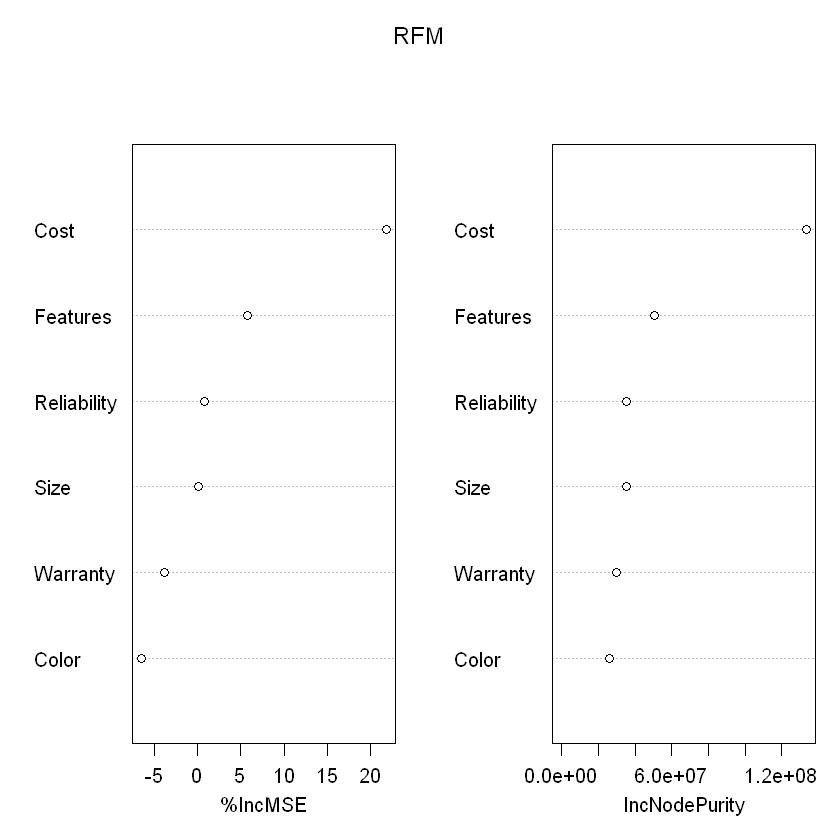

In [3]:
# Random Forest
library(randomForest)
RFM=randomForest(Sales~.,data=ps, importance=TRUE)
importance(RFM)
varImpPlot(RFM)

8 x 1 sparse Matrix of class "dgCMatrix"
                seg67
intercept   3338.6351
(Intercept)    .     
Color          .     
Size         302.2088
Features     365.7851
Reliability  382.6246
Warranty       .     
Cost        1041.1788

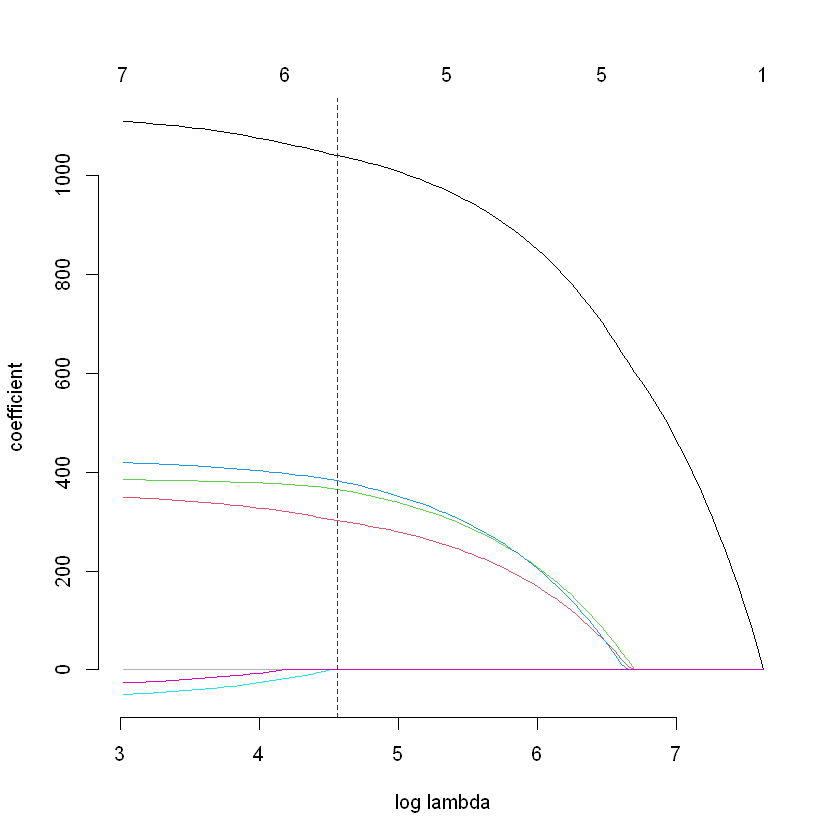

In [5]:
# Lasso Regression
# Note these variables are all on the same scale, so no standardization is needed.
# install.packages("gamlr")
library(gamlr)
modMat<-model.matrix(~Color+Size+Features+Reliability+Warranty+Cost, data=ps)
fit<-gamlr(x=modMat,y=ps$Sales)
plot(fit)
coef(fit)

# Summary example 1
• All three methods of variable selection agreed that Color and
Warranty should not be used in the model

• The process for building the final model would now begin using just
the selected columns: Size, Features, Reliability, and Cost

Stepwise Model Path 
Analysis of Deviance Table

Initial Model:
Sales ~ Color + Size + Features + Reliability + Warranty + Cost

Final Model:
Sales ~ Size + Features + Reliability + Cost


        Step Df Deviance Resid. Df Resid. Dev      AIC
1                               33   94345556 600.9438
2    - Color  1 235310.4        34   94580867 599.0435
3 - Warranty  1 652013.5        35   95232880 597.3183


,%IncMSE,IncNodePurity
Color,-4.053224,27543916
Size,1.041399,39811074
Features,4.875800,49567004
Reliability,2.102222,33853673
Warranty,-2.260254,30099581
Cost,20.558177,133577775


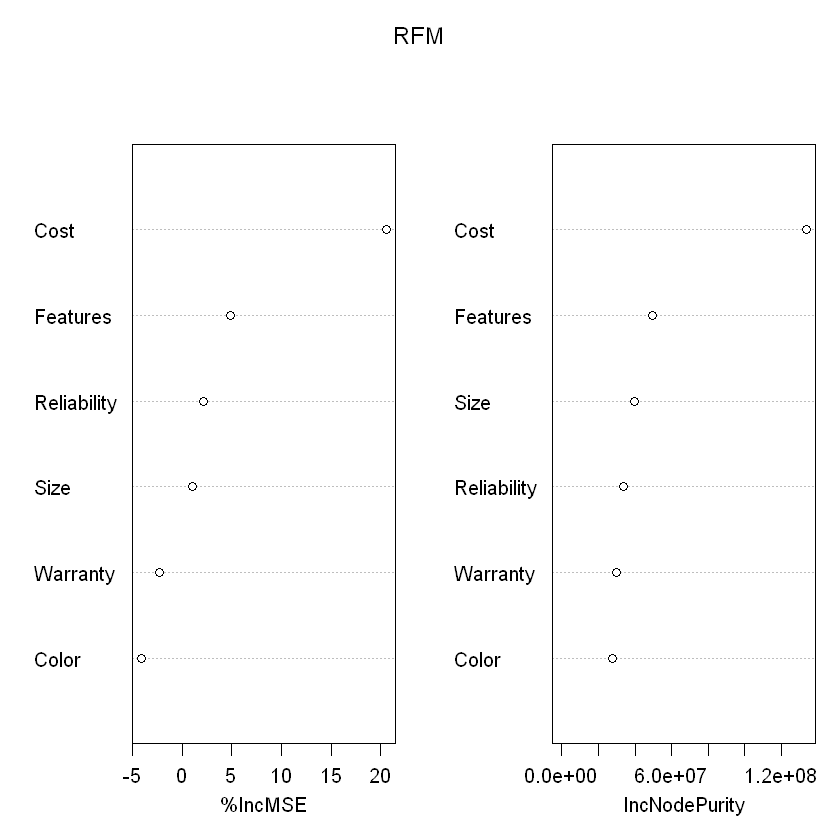

8 x 1 sparse Matrix of class "dgCMatrix"
                seg67
intercept   3338.6351
(Intercept)    .     
Color          .     
Size         302.2088
Features     365.7851
Reliability  382.6246
Warranty       .     
Cost        1041.1788

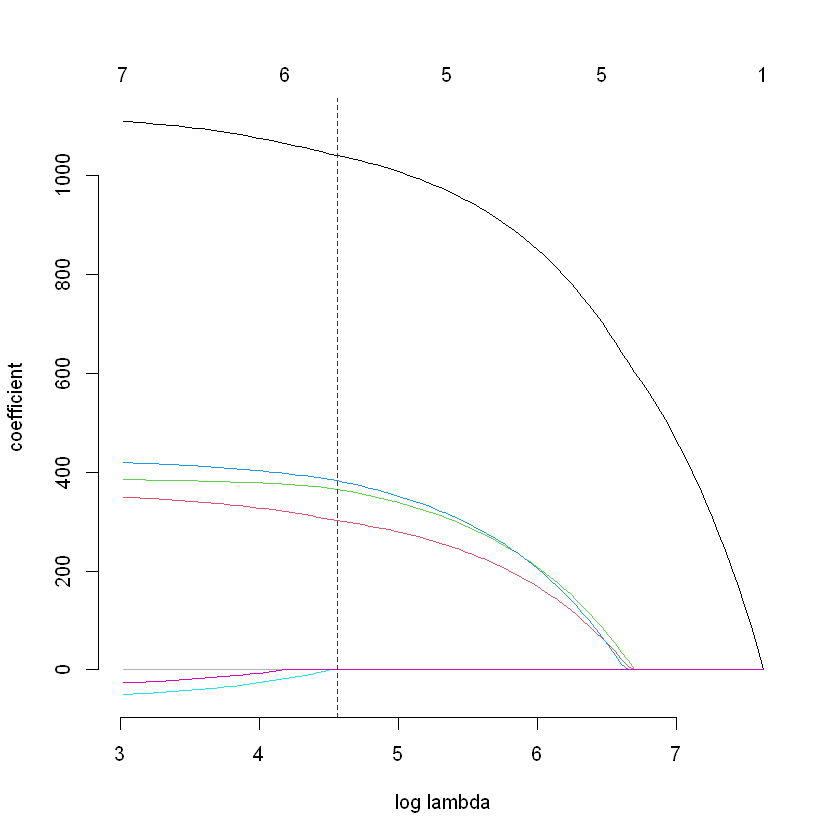

In [6]:
# Full program Using Three Selection Techniques

#stepwise
#install.packages("MASS")
library(MASS)
step_model <- stepAIC(lm(Sales ~ ., data = ps), direction = "both", trace = FALSE)
print(step_model$anova)
#RF
#install.packages("randomForest")
library(randomForest)
RFM=randomForest(Sales~.,data=ps, importance=TRUE)
importance(RFM)
varImpPlot(RFM)
#Lasso
#install.packages("gamlr")
library(gamlr)
modMat<-model.matrix(~Color+Size+Features+Reliability+Warranty+Cost, data=ps)
fit<-gamlr(x=modMat,y=ps$Sales)
plot(fit)
coef(fit)

# Example 2
The file “irs2.csv” contains data from past US Internal Revenue Service audits. In an effort to more efficiently audit only those returns most likely to have violated tax laws, the columns in the file irs2.csv are:

• cheated: "yes" if the audit found the return violated tax laws, otherwise "no" -- this is the target
variable we are building the model to predict

• married: "yes" if the return is for a married individual; "no" for single

• dependents: "yes" if the return is for an individual claiming dependents; "no" otherwise

• incomeOver100K: "yes" if the income of the individual exceeds $100,000

• return: "yes" if the individual received a return ("no" if a the individual did not receive a return or
had to pay in)

• Largedonation: “yes” if the individual made a donation in excess of 10% of their annual income,
no otherwise

• mathErrors: “yes”: if there were math errors in the return, “no” otherwise

• filedLate: "yes" if the return was filed late, "no" if filed early or on time

• Over4DeductClaimed: "yes" if over 4 deductions were claimed, "no" if 4 or less

In [10]:
irs <-read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/irs2.csv", header=TRUE)
# head(irs)
# ==============================================
# An extra step is required for stepwise selection for categorical data, to turn the “yes” and “no”s into 1’s and 0’s (called dummy variables or indicator variables)
# ==============================================
# Dummy code categorical predictor variables
irsdum <- model.matrix(~., irs)[,-1]
irsdum<-data.frame(irsdum)
head(irsdum)
#install.packages("MASS")
library(MASS)
step_model <- stepAIC(lm(cheatedyes ~ ., data = irsdum, family=binomial), direction = "both", trace = FALSE)
# Print the selected variables
print(step_model$anova)

,cheatedyes,marriedyes,dependentsyes,incomeOver100Kyes,returnyes,largedonationyes,mathErrorsyes,filedLateyes,Over4DeductClaimedyes
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0,0,1,0,0,1,0,0
2,0,1,1,1,0,0,1,0,0
3,0,1,0,1,0,1,0,0,0
4,1,0,0,1,0,0,1,0,0
5,0,1,0,1,1,1,0,0,1
6,0,1,1,1,1,1,1,1,0


Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"
Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"
Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"
Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"


Stepwise Model Path 
Analysis of Deviance Table

Initial Model:
cheatedyes ~ marriedyes + dependentsyes + incomeOver100Kyes + 
    returnyes + largedonationyes + mathErrorsyes + filedLateyes + 
    Over4DeductClaimedyes

Final Model:
cheatedyes ~ marriedyes + incomeOver100Kyes + returnyes + filedLateyes + 
    Over4DeductClaimedyes


                Step Df    Deviance Resid. Df Resid. Dev       AIC
1                                         477   41.48767 -1177.955
2    - dependentsyes  1 0.006368431       478   41.49404 -1179.880
3    - mathErrorsyes  1 0.010191336       479   41.50423 -1181.761
4 - largedonationyes  1 0.078835478       480   41.58306 -1182.839


,no,yes,MeanDecreaseAccuracy,MeanDecreaseGini
married,30.2107992,32.643831,35.4944119,19.095862
dependents,-2.6617553,4.433582,1.1922954,2.575016
incomeOver100K,31.9915824,36.722383,39.7238682,24.596285
return,34.6145234,37.657000,41.4176848,25.548216
largedonation,-0.2537734,1.571795,0.8743907,2.560556
mathErrors,0.8194591,-1.327578,-0.2104777,2.610657
filedLate,27.3646656,25.982851,31.5898077,14.334619
Over4DeductClaimed,22.8667001,25.462286,29.0039167,14.180614


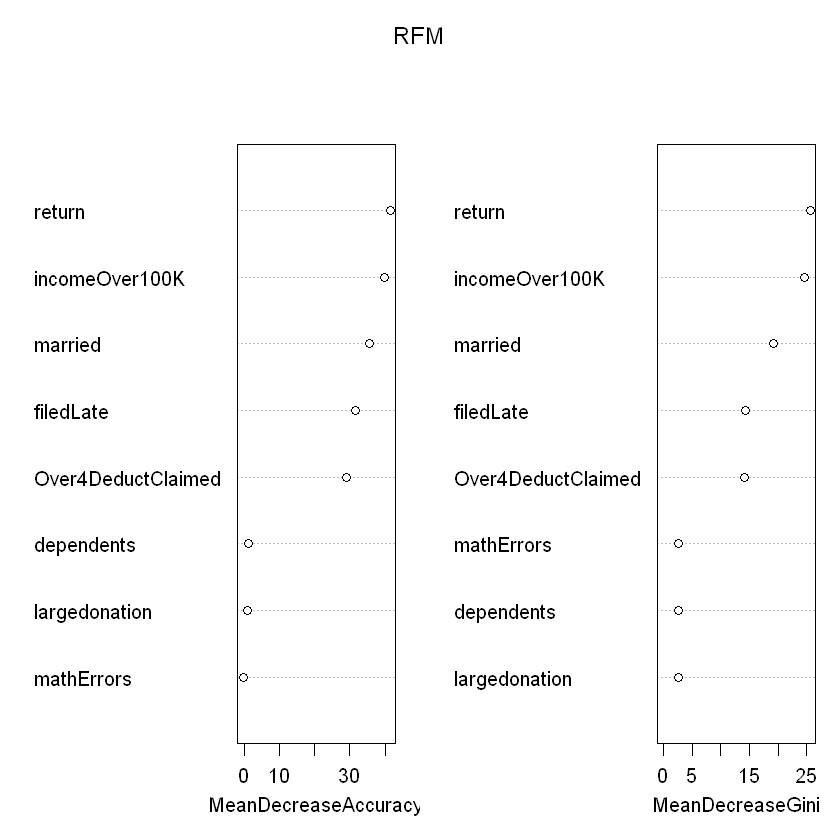

In [11]:
# Random Forest
# head(irs)
irs$cheated<-factor(irs$cheated)
RFM=randomForest(cheated~.,data=irs, importance=TRUE)
importance(RFM)
varImpPlot(RFM)
# (Note, there is no need to recode the data into dummy variables for random forests)

Importance using accuracy is given in the first graph; importance using the Gini criterion is given in the second—either could be used to determine which variables are most useful for building a model

In this case, there is a clear drop-off for largedonation, mathErrors, and dependents, indicating they should not be used.

10 x 1 sparse Matrix of class "dgCMatrix"
                           seg99
intercept             -2.5741270
(Intercept)            .        
marriedyes            -3.6222103
dependentsyes          .        
incomeOver100Kyes      4.1429629
returnyes             -4.7533481
largedonationyes      -0.1616757
mathErrorsyes          .        
filedLateyes           4.2112906
Over4DeductClaimedyes  4.0355239

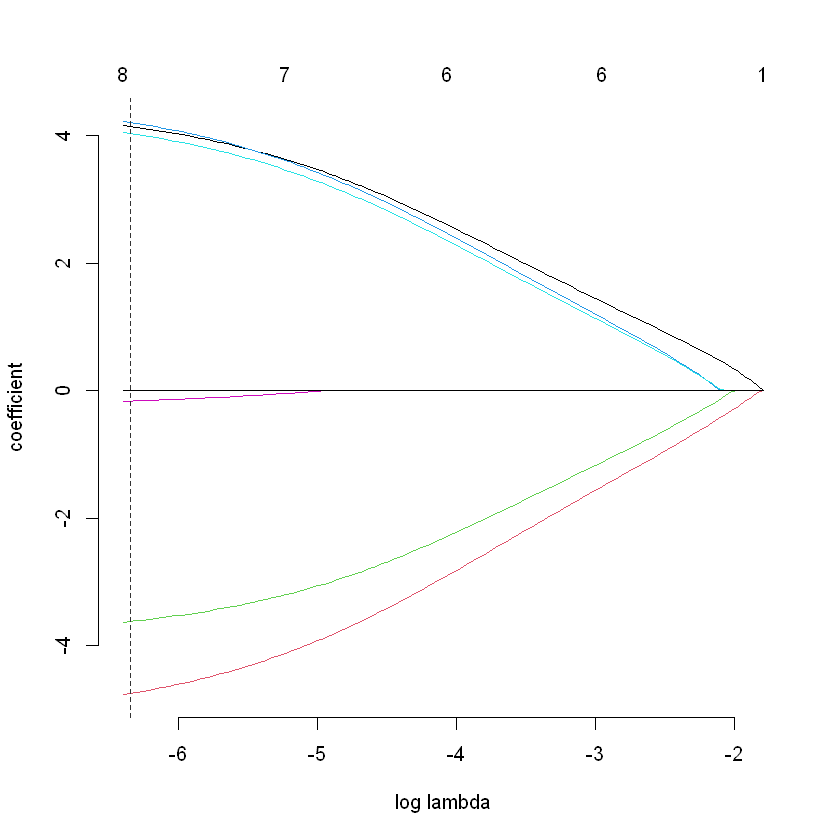

In [12]:
# Dummy code categorical predictor variables
irsdum <- model.matrix(~., irs)[,-1]
irsdum<-data.frame(irsdum)
#head(irsdum)
#lasso regression
#install.packages("gamlr")
library(gamlr)
modMat<-model.matrix(~marriedyes + dependentsyes + incomeOver100Kyes +
returnyes + largedonationyes + mathErrorsyes + filedLateyes +
Over4DeductClaimedyes, data=irsdum)
fit<-gamlr(x=modMat,y=irsdum$cheatedyes, family = "binomial")
plot(fit)
coef(fit)

# Note these variables are all on the same scale, so no standardization is needed.
# However, dummy variables will again need to be created for the lasso technique

# Summary example 2
• All three methods of variable selection agreed that dependents and
mathErrors should not be used in the model
• Stepwise and Random Forests indicated largedonation should also be
removed
• Further, largedonation was selected late in the regularization path
from the Lasso
• The final model selected would likely not use these three columns
and instead be based on married, incomeOver100K, return, filedLate,
and Over4DeductClaimedyes (these were the variables you used to
build your ANN in week 8)

,cheatedyes,marriedyes,dependentsyes,incomeOver100Kyes,returnyes,largedonationyes,mathErrorsyes,filedLateyes,Over4DeductClaimedyes
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0,0,1,0,0,1,0,0
2,0,1,1,1,0,0,1,0,0
3,0,1,0,1,0,1,0,0,0
4,1,0,0,1,0,0,1,0,0
5,0,1,0,1,1,1,0,0,1
6,0,1,1,1,1,1,1,1,0


Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"
Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"
Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"
Warning message:
"In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument 'family' will be disregarded"


Stepwise Model Path 
Analysis of Deviance Table

Initial Model:
cheatedyes ~ marriedyes + dependentsyes + incomeOver100Kyes + 
    returnyes + largedonationyes + mathErrorsyes + filedLateyes + 
    Over4DeductClaimedyes

Final Model:
cheatedyes ~ marriedyes + incomeOver100Kyes + returnyes + filedLateyes + 
    Over4DeductClaimedyes


                Step Df    Deviance Resid. Df Resid. Dev       AIC
1                                         477   41.48767 -1177.955
2    - dependentsyes  1 0.006368431       478   41.49404 -1179.880
3    - mathErrorsyes  1 0.010191336       479   41.50423 -1181.761
4 - largedonationyes  1 0.078835478       480   41.58306 -1182.839


,no,yes,MeanDecreaseAccuracy,MeanDecreaseGini
married,30.664709,27.84279026,33.5936942,18.520047
dependents,-1.732076,1.50535336,-0.1020381,2.684372
incomeOver100K,30.008379,34.62150743,36.1303782,24.219483
return,35.468778,38.28493455,41.4700735,25.256653
largedonation,0.374092,1.54452473,1.4348773,2.588916
mathErrors,1.545590,-0.08012093,1.1500930,2.479967
filedLate,26.236860,25.55521136,30.9787654,14.205874
Over4DeductClaimed,21.484848,23.69838295,27.0116366,14.457942


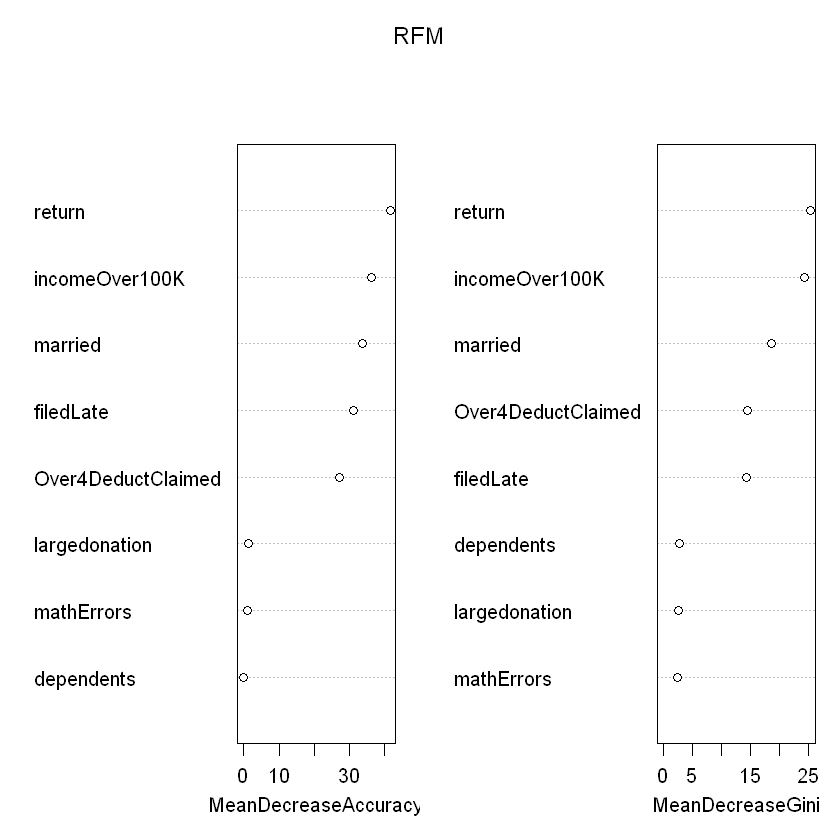

10 x 1 sparse Matrix of class "dgCMatrix"
                           seg99
intercept             -2.5741270
(Intercept)            .        
marriedyes            -3.6222103
dependentsyes          .        
incomeOver100Kyes      4.1429629
returnyes             -4.7533481
largedonationyes      -0.1616757
mathErrorsyes          .        
filedLateyes           4.2112906
Over4DeductClaimedyes  4.0355239

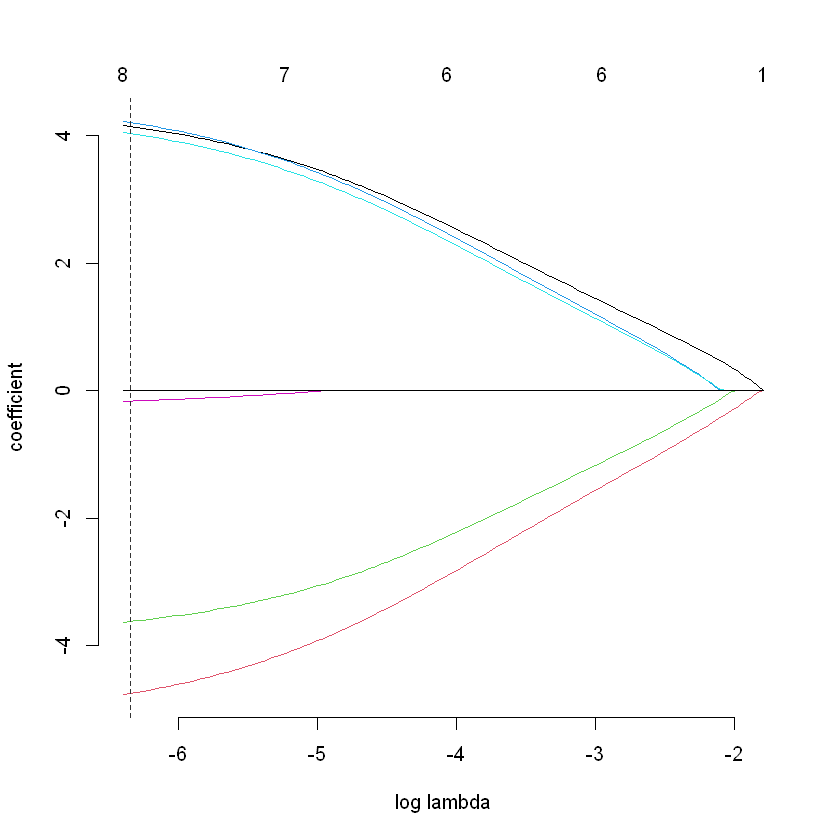

In [14]:
# Full program Using Three Selection Techniques
#Stepwise AIC
irsdum <- model.matrix(~., irs)[,-1]
irsdum<-data.frame(irsdum)
head(irsdum)
library(MASS)
step_model <- stepAIC(lm(cheatedyes ~ ., data = irsdum, family=binomial), direction = "both", trace =
FALSE)
print(step_model$anova)
#RF
RFM=randomForest(cheated~.,data=irs, importance=TRUE)
importance(RFM)
varImpPlot(RFM)
#LASSO
library(gamlr)
modMat<-model.matrix(~marriedyes + dependentsyes + incomeOver100Kyes + returnyes +
largedonationyes + mathErrorsyes + filedLateyes + Over4DeductClaimedyes, data=irsdum)
fit<-gamlr(x=modMat,y=irsdum$cheatedyes, family = "binomial")
plot(fit)
coef(fit)